# AIMS 5790 — Influence Function Analysis on Lean4 Proof Data

**Pipeline**: Setup → Data → QLoRA → Gradient → Influence → Analysis → Curriculum


---
## 1. Setup

In [9]:
!pip install pandas==2.2.2
!pip install -q -U transformers datasets peft trl accelerate bitsandbytes safetensors scipy scikit-learn matplotlib seaborn tqdm huggingface-hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 130.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 205.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 149.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 78.9 MB/s eta 0:00:00


In [2]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
try:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/MyDrive/AIMS5790"
except ImportError:
    ROOT = "./AIMS5790_outputs"
os.makedirs(ROOT, exist_ok=True)
print(f"结果将保存到: {ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
结果将保存到: /content/drive/MyDrive/AIMS5790


In [ ]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

CUDA: True
Device: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
# Config
CONFIG = {
    "MODEL_ID": "Qwen/Qwen2.5-0.5B-Instruct",
    "max_seq_length": 1024,
    "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.05,
    "epochs": 5, "batch_size": 1, "grad_accum": 8, "lr": 2e-4,
    "top_k": 100, "bot_k": 100,
}

---
## 2. Data Preparation & EDA

In [ ]:
from datasets import load_dataset

def filter_human_complete_proofs(ds, min_proof_len=20, min_statement_len=5):
    def _filter(ex):
        if ex.get("author") != "human": return False
        if ex.get("ground_truth_type") != "complete": return False
        proof = (ex.get("formal_ground_truth") or "").strip()
        stmt = (ex.get("formal_statement") or "").strip()
        if len(proof) < min_proof_len or len(stmt) < min_statement_len: return False
        if "sorry" in proof.lower(): return False
        return True
    return ds.filter(_filter)

def deduplicate(ds):
    seen, keep = set(), []
    for i in range(len(ds)):
        ex = ds[i]
        key = (ex.get("formal_statement", ""), ex.get("formal_ground_truth", ""))
        if key in seen: continue
        seen.add(key)
        keep.append(i)
    return ds.select(keep)

def format_sample(stmt, proof):
    return f"### Theorem:\n{stmt.strip()}\n\n### Proof:\n{proof.strip()}"

ds = load_dataset("AI-MO/NuminaMath-LEAN", split="train", trust_remote_code=True)
print(f"Raw: {len(ds)}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AI-MO/NuminaMath-LEAN' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AI-MO/NuminaMath-LEAN' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


Raw: 104155


In [ ]:
ds_filtered = filter_human_complete_proofs(ds)
ds_filtered = deduplicate(ds_filtered)
print(f"Filtered: {len(ds_filtered)}")

Filtered: 9442


In [ ]:
ds_split = ds_filtered.train_test_split(test_size=0.1, seed=42)
ds_val_test = ds_split["test"].train_test_split(test_size=0.5, seed=42)
ds_train = ds_split["train"]
ds_val = ds_val_test["train"]
ds_test = ds_val_test["test"]
print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}")

Train: 8497, Val: 472, Test: 473


In [ ]:
def add_text(ex):
    ex["text"] = format_sample(ex["formal_statement"], ex["formal_ground_truth"])
    return ex

ds_train = ds_train.map(add_text, desc="Format")
ds_val = ds_val.map(add_text, desc="Format")
ds_test = ds_test.map(add_text, desc="Format")

Format:   0%|          | 0/8497 [00:00<?, ? examples/s]

Format:   0%|          | 0/472 [00:00<?, ? examples/s]

Format:   0%|          | 0/473 [00:00<?, ? examples/s]

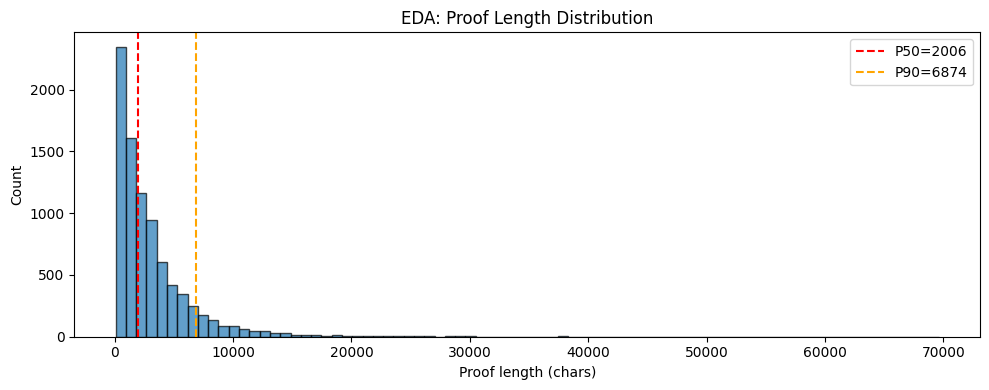

Mean: 3080.7800400141227
Median: 2006.0
P90: 6874.200000000004
Max: 69614


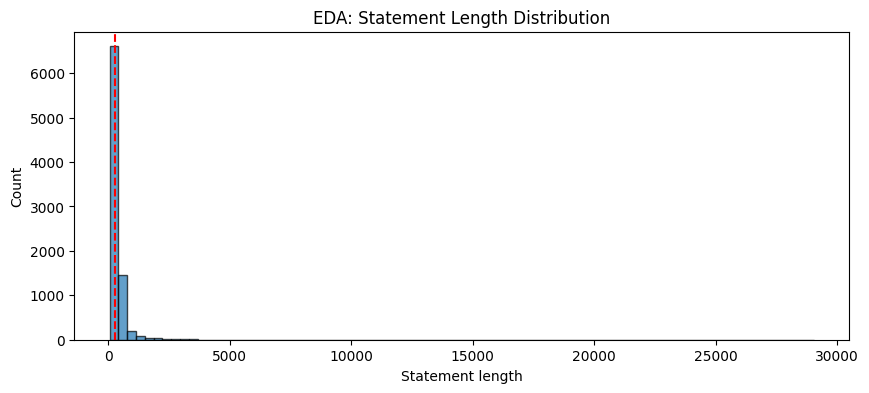

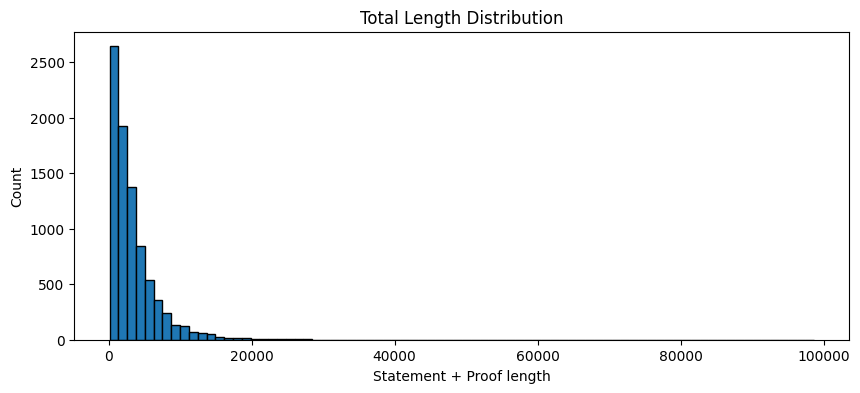

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

lengths = [len(ex["formal_ground_truth"]) for ex in ds_train]
plt.figure(figsize=(10,4))
plt.hist(lengths, bins=80, edgecolor="black", alpha=0.7)
plt.axvline(np.median(lengths), color="red", linestyle="--", label=f"P50={np.median(lengths):.0f}")
plt.axvline(np.percentile(lengths, 90), color="orange", linestyle="--", label=f"P90={np.percentile(lengths,90):.0f}")
plt.xlabel("Proof length (chars)")
plt.ylabel("Count")
plt.legend()
plt.title("EDA: Proof Length Distribution")
plt.tight_layout()
plt.show()
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("P90:", np.percentile(lengths,90))
print("Max:", np.max(lengths))

statement_lengths = [len(ex["formal_statement"]) for ex in ds_train]

plt.figure(figsize=(10,4))
plt.hist(statement_lengths, bins=80, edgecolor="black", alpha=0.7)

plt.axvline(np.median(statement_lengths), color="red", linestyle="--")

plt.title("EDA: Statement Length Distribution")
plt.xlabel("Statement length")
plt.ylabel("Count")
plt.show()

total_lengths = [
    len(ex["formal_statement"]) + len(ex["formal_ground_truth"])
    for ex in ds_train
]

plt.figure(figsize=(10,4))
plt.hist(total_lengths, bins=80, edgecolor="black")

plt.title("Total Length Distribution")
plt.xlabel("Statement + Proof length")
plt.ylabel("Count")
plt.show()

In [ ]:
import os
os.makedirs("./data", exist_ok=True)
ds_train.save_to_disk(ROOT +"/data/train")
ds_val.save_to_disk(ROOT +"/data/val")
ds_test.save_to_disk(ROOT +"/data/test")
print("Data saved.")

Saving the dataset (0/1 shards):   0%|          | 0/8497 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/472 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/473 [00:00<?, ? examples/s]

Data saved.


---
## 3. QLoRA Training

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype="bfloat16",
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_ID"], quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, LoraConfig(r=CONFIG["lora_r"], lora_alpha=CONFIG["lora_alpha"], lora_dropout=CONFIG["lora_dropout"], bias="none", target_modules=["q_proj","k_proj","v_proj","o_proj"], task_type="CAUSAL_LM"))
print("Model loaded.")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded.


In [ ]:
args = SFTConfig(
    output_dir="./outputs/qlora",
    max_length=CONFIG["max_seq_length"],
    dataset_text_field="text", packing=False,
    num_train_epochs=CONFIG["epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["grad_accum"],
    learning_rate=CONFIG["lr"],
    max_grad_norm=0.3, warmup_steps=50, lr_scheduler_type="cosine",
    logging_steps=10, save_strategy="epoch", bf16=True,
    eval_strategy="epoch", load_best_model_at_end=True,
)
trainer = SFTTrainer(
    model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
)
trainer.train()
trainer.save_model(ROOT+"/outputs/qlora/adapter")
print("Training done.")

Adding EOS to train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/472 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/472 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/472 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.875316,0.829620
2,0.763835,0.797986
3,0.786629,0.795196


Training done.


---
## 4. Gradient Extraction

In [ ]:
from peft import PeftModel
from tqdm import tqdm

base = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_ID"], quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
)
model = PeftModel.from_pretrained(base, "./outputs/qlora/adapter", is_trainable=True)
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Line

In [ ]:
def extract_grad_single(model, tokenizer, text, max_len, device="cuda"):
    model.train()
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len, padding="max_length", return_attention_mask=True)
    enc = {k: v.to(device) for k, v in enc.items()}
    labels = enc["input_ids"].clone()
    labels[enc["attention_mask"] == 0] = -100
    out = model(**enc, labels=labels)
    out.loss.backward()
    grads = {n: p.grad.detach().float().cpu().clone() for n, p in model.named_parameters() if p.requires_grad and p.grad is not None}
    model.zero_grad()
    model.eval()
    return grads, out.loss.item()

In [ ]:
def flatten(g):
    return torch.cat([v.flatten() for v in g.values()])

os.makedirs("/outputs/grads", exist_ok=True)
max_len = CONFIG["max_seq_length"]
GRAD_SUBSET = None
n_train = min(len(ds_train), GRAD_SUBSET) if GRAD_SUBSET else len(ds_train)

sum_g2, train_losses = None, []
for i in tqdm(range(n_train), desc="Train grads (pass 1)"):
    g, loss = extract_grad_single(model, tokenizer, ds_train[i]["text"], max_len)
    f = flatten(g)
    sum_g2 = f.pow(2) if sum_g2 is None else sum_g2 + f.pow(2)
    train_losses.append(loss)
    del g, f

torch.save({"sum_g2": sum_g2, "losses": train_losses, "n": n_train}, ROOT + "/outputs/grads/train_grads.pt")
print(f"Pass 1 done. n={n_train}")

Train grads (pass 1): 100%|██████████| 8497/8497 [41:52<00:00,  3.38it/s]


Pass 1 done. n=8497


In [ ]:
g_val, n_val = None, 0
for i in tqdm(range(len(ds_val)), desc="Val grads"):
    g, _ = extract_grad_single(model, tokenizer, ds_val[i]["text"], max_len)
    f = flatten(g)
    if g_val is None: g_val = f.clone()
    else: g_val = g_val + f
    n_val += 1
    del g, f
g_val = g_val / n_val
torch.save({"g_val": g_val}, ROOT + "/outputs/grads/val_grads.pt")
print("Val gradient saved.")

Val grads: 100%|██████████| 472/472 [02:20<00:00,  3.37it/s]

Val gradient saved.


---
## 5. Influence Computation (DataInf)

In [ ]:
import numpy as np

data = torch.load(ROOT + "/outputs/grads/train_grads.pt")
sum_g2, train_losses, n_train = data["sum_g2"], data["losses"], data["n"]
g_val = torch.load(ROOT + "/outputs/grads/val_grads.pt")["g_val"]

diag_H = (sum_g2 / n_train) + 1e-8
inv_diag_H = 1.0 / diag_H
g_val_flat = g_val

In [ ]:
influences = []
for i in tqdm(range(n_train), desc="Influence (pass 2)"):
    g, _ = extract_grad_single(model, tokenizer, ds_train[i]["text"], CONFIG["max_seq_length"])
    f = flatten(g)
    inf = -(g_val_flat * inv_diag_H * f).sum().item()
    influences.append(inf)
    del g, f
influences = np.array(influences)

top_k, bot_k = CONFIG["top_k"], CONFIG["bot_k"]
top_idx = np.argsort(influences)[-top_k:][::-1]
bot_idx = np.argsort(influences)[:bot_k]

print("Top helpful (sample idx):", top_idx[:10], "\nInfluence:", influences[top_idx[:10]])
print("Top harmful (sample idx):", bot_idx[:10], "\nInfluence:", influences[bot_idx[:10]])

Influence (pass 2): 100%|██████████| 8497/8497 [42:22<00:00,  3.34it/s]

Top helpful (sample idx): [ 988 1673 6126 6656 5695] 
Influence: [11216.171875   11074.43164062 10184.67382812  8789.05859375
  8562.28808594]
Top harmful (sample idx): [5229 7725 3991 3601 7380] 
Influence: [-57908.625      -56767.67578125 -50391.21484375 -50218.68359375
 -50034.328125  ]


Top helpful (sample idx): [ 988 1673 6126 6656 5695  722 7876 1828 4459 4238]
Influence: [11216.171875   11074.43164062 10184.67382812  8789.05859375
  8562.28808594  8375.15039062  8350.09667969  8256.2734375
  8210.98242188  7888.21289062]

Top harmful (sample idx): [5229 7725 3991 3601 7380 7592 3086 6606 4059 2908]
Influence: [-57908.625      -56767.67578125 -50391.21484375 -50218.68359375
 -50034.328125   -49360.32421875 -49351.57421875 -48887.421875
 -48840.9140625  -48692.8046875 ]


/tmp/ipykernel_41820/3104109870.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(
/tmp/ipykernel_41820/3104109870.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(


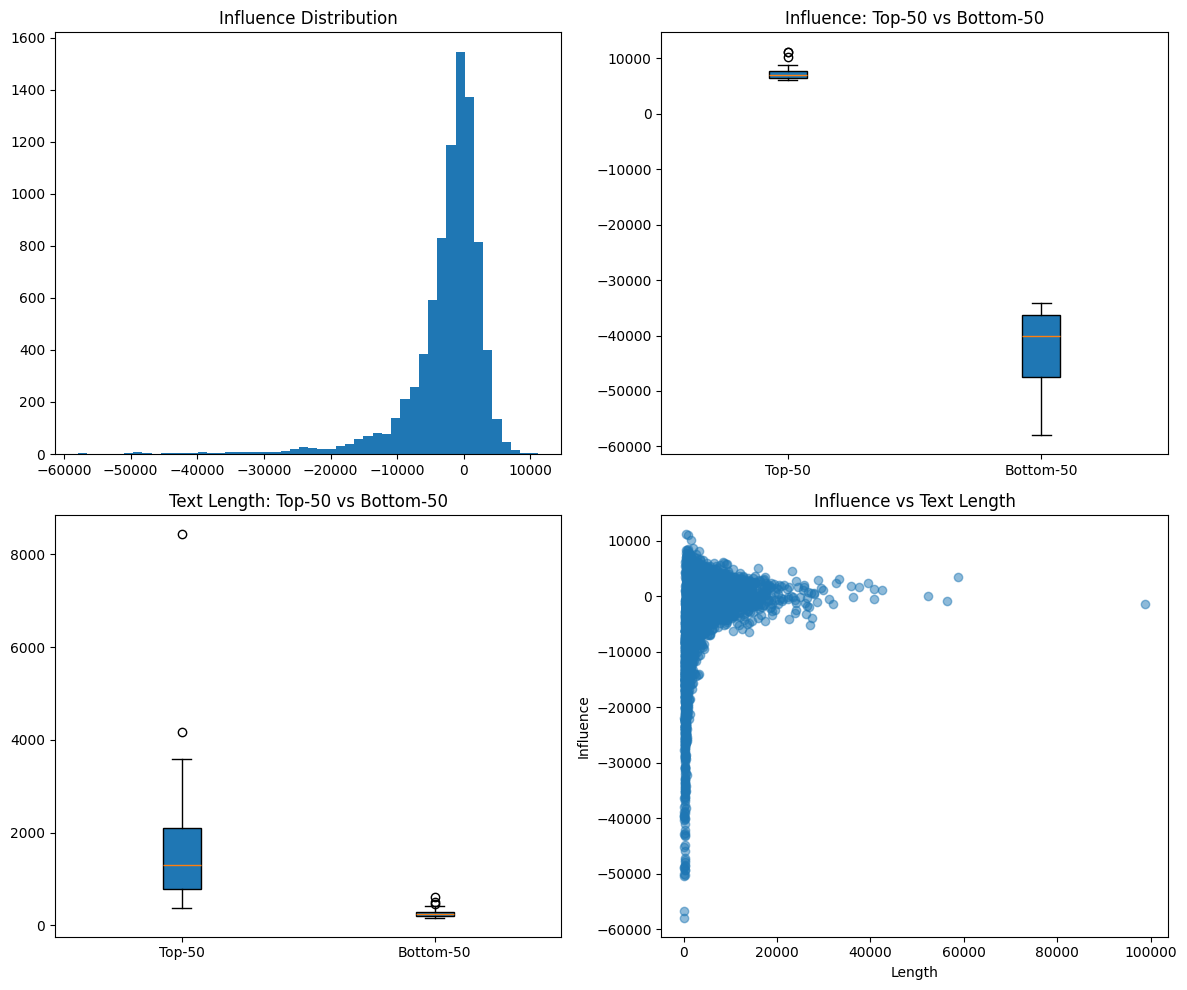


--- Top 10 Most Helpful ---
#1 influence=11216.171875 len=477
### Theorem:
import Mathlib
open Nat
/-Let $S=M_{13}+5$. Compute the product of all positive divisors of $S$.-/
set_option maxRecDepth 12000 in
theorem Number_Theory_610015 : (mersenne 13 + 5).divisor

#2 influence=11074.431641 len=905
### Theorem:
import Mathlib
open Polynomial

/-Given the function $f(x)=x^{3}+ax^{2}+3x-9$, find the value of $a$ such that $f(x)$ attains an extreme value at $x=-3$.-/
noncomputable def f_9226 (a : ℝ

#3 influence=10184.673828 len=1671
### Theorem:
import Mathlib
open Real

/-
If $a, b$ are nonzero real numbers such that $a^{2}+b^{2}=8 a b$, find the value of $\left|\frac{a+b}{a-b}\right|$.
-/
theorem algebra_611463 (a b : ℝ) (ha : 

#4 influence=8789.058594 len=2075
### Theorem:
import Mathlib

/-Find all prime numbers $p$ and $q$ for which $p^{2} - 2 q^{2}=1$.-/
theorem number_theory_197142 {p q : ℕ} (hp : p.Prime) (hq : q.Prime) :
    p^2 - 2 * q^2 = 1 ↔ (p = 3

#5 influence=8562.288086 l

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sorted_idx = np.argsort(influences)

top_k = CONFIG["top_k"]
bot_k = CONFIG["bot_k"]

top_idx = sorted_idx[-top_k:][::-1]
bot_idx = sorted_idx[:bot_k]

print("Top helpful (sample idx):", top_idx[:10])
print("Influence:", influences[top_idx[:10]])

print("\nTop harmful (sample idx):", bot_idx[:10])
print("Influence:", influences[bot_idx[:10]])

# ===== 计算文本长度 =====
def get_len(sample):
    if "text" in sample:
        return len(sample["text"])
    elif "proof" in sample:
        return len(sample["proof"])
    else:
        return len(str(sample))

top_lengths = [get_len(ds_train[i]) for i in top_idx[:50]]
bot_lengths = [get_len(ds_train[i]) for i in bot_idx[:50]]

# ===== 画图 =====
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1 Influence distribution
axes[0,0].hist(influences, bins=50)
axes[0,0].set_title("Influence Distribution")

# 2 Top vs Bottom influence
axes[0,1].boxplot(
    [influences[top_idx[:50]], influences[bot_idx[:50]]],
    labels=["Top-50", "Bottom-50"],
    patch_artist=True
)
axes[0,1].set_title("Influence: Top-50 vs Bottom-50")

# 3 Text length comparison
axes[1,0].boxplot(
    [top_lengths, bot_lengths],
    labels=["Top-50", "Bottom-50"],
    patch_artist=True
)
axes[1,0].set_title("Text Length: Top-50 vs Bottom-50")

# 4 Influence vs Length scatter
lengths = [get_len(ds_train[i]) for i in range(len(ds_train))]
axes[1,1].scatter(lengths, influences, alpha=0.5)
axes[1,1].set_title("Influence vs Text Length")
axes[1,1].set_xlabel("Length")
axes[1,1].set_ylabel("Influence")

plt.tight_layout()
plt.show()

# ===== 打印 Top / Bottom 样本 =====
print("\n--- Top 10 Most Helpful ---")
for rank, idx in enumerate(top_idx[:10]):
    sample = ds_train[idx]
    text = sample.get("text","")[:200]  # 只打印前200字符
    print(f"#{rank+1} influence={influences[idx]:.6f} len={get_len(sample)}")
    print(text)
    print()

print("\n--- Bottom 10 Most Harmful ---")
for rank, idx in enumerate(bot_idx[:10]):
    sample = ds_train[idx]
    text = sample.get("text","")[:200]
    print(f"#{rank+1} influence={influences[idx]:.6f} len={get_len(sample)}")
    print(text)
    print()

In [ ]:
os.makedirs(ROOT + "/outputs", exist_ok=True)
np.savez(ROOT + "/outputs/influence_scores.npz", influences=influences, top_idx=top_idx, bot_idx=bot_idx)
print("Influence scores saved.")

Influence scores saved.


---
## 6. Importance & Multi-Proof Analysis

In [ ]:
import pandas as pd
from collections import defaultdict

data = np.load(ROOT + "/outputs/influence_scores.npz")
influences = data["influences"]
top_idx, bot_idx = data["top_idx"], data["bot_idx"]
train_losses = torch.load(ROOT + "/outputs/grads/train_grads.pt")["losses"]

pct = 0.1
n = len(influences)
top_pct_idx = np.argsort(influences)[-int(n*pct):][::-1]
bot_pct_idx = np.argsort(influences)[:int(n*pct)]

def stats(idx, name):
    lens = [len(ds_train[i]["formal_ground_truth"]) for i in idx]
    losses = [train_losses[i] for i in idx]
    return {"name": name, "len_mean": np.mean(lens), "len_std": np.std(lens), "loss_mean": np.mean(losses), "loss_std": np.std(losses)}

df = pd.DataFrame([stats(top_pct_idx, "Top 10%"), stats(bot_pct_idx, "Bottom 10%")])
print("=== High vs Low Importance ===")
print(df)

=== High vs Low Importance ===
         name     len_mean      len_std  loss_mean  loss_std
0     Top 10%  3807.338045  4232.483301   0.761764   0.23857
1  Bottom 10%   528.471143   540.272330   0.716107   0.23845


In [ ]:
stmt_to_idx = defaultdict(list)
for i in range(len(ds_train)):
    stmt_to_idx[ds_train[i]["formal_statement"].strip()].append(i)
multi = {k: v for k, v in stmt_to_idx.items() if len(v) >= 2}
print(f"Theorems with >=2 proofs: {len(multi)}")

Theorems with >=2 proofs: 6


In [ ]:
rows = []
for stmt, idxs in list(multi.items())[:200]:
    infs = influences[idxs]
    lens = [len(ds_train[i]["formal_ground_truth"]) for i in idxs]
    rows.append({"n_proofs": len(idxs), "max_inf": infs.max(), "min_inf": infs.min(), "var_inf": infs.var(), "len_gap": max(lens)-min(lens)})
df_mp = pd.DataFrame(rows)
print("=== Multi-Proof Stats ===")
print(df_mp.describe())

=== Multi-Proof Stats ===
       n_proofs      max_inf       min_inf       var_inf      len_gap
count       6.0     6.000000      6.000000  6.000000e+00     6.000000
mean        2.0 -4076.501790  -6453.777791  1.863682e+06   477.333333
std         0.0  3540.836322   3687.712703  1.439707e+06   586.209746
min         2.0 -9120.617188 -12855.271484  3.793970e+03     1.000000
25%         2.0 -6015.515747  -7309.546265  6.611851e+05    74.500000
50%         2.0 -3807.941650  -6161.013672  2.304666e+06   287.000000
75%         2.0 -2509.903687  -4298.511475  2.802690e+06   624.750000
max         2.0  1106.087891  -2175.300049  3.486911e+06  1548.000000


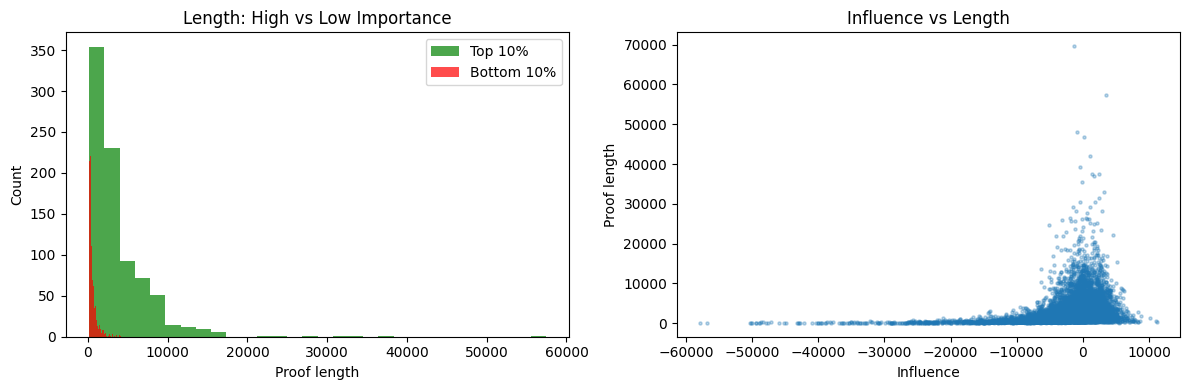

Saved: /content/drive/MyDrive/AIMS5790/outputs/importance_analysis.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([len(ds_train[i]["formal_ground_truth"]) for i in top_pct_idx], bins=30, alpha=0.7, label="Top 10%", color="green")
axes[0].hist([len(ds_train[i]["formal_ground_truth"]) for i in bot_pct_idx], bins=30, alpha=0.7, label="Bottom 10%", color="red")
axes[0].set_xlabel("Proof length")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].set_title("Length: High vs Low Importance")

axes[1].scatter(influences, [len(ds_train[i]["formal_ground_truth"]) for i in range(len(ds_train))], alpha=0.3, s=5)
axes[1].set_xlabel("Influence")
axes[1].set_ylabel("Proof length")
axes[1].set_title("Influence vs Length")
plt.tight_layout()
plt.savefig(ROOT + "/outputs/importance_analysis.png", dpi=150)
plt.show()
print(f"Saved: {ROOT}/outputs/importance_analysis.png")

---
## 7. Curriculum Learning

In [ ]:
def add_difficulty(example):
    text = example["text"]

    length = len(text)
    steps = text.count("\n")
    equations = text.count("=")
    arrows = text.count("→")

    example["difficulty"] = length + 10 * steps + 5 * equations + 5 * arrows
    return example

ds_train = ds_train.map(add_difficulty)

Map:   0%|          | 0/8497 [00:00<?, ? examples/s]

In [ ]:
from datasets import interleave_datasets

def get_ordered_dataset(strategy, seed):
    assert "difficulty" in ds_train.column_names

    ds = ds_train  # 🔥 不 shuffle，保证 curriculum 稳定

    if strategy == "random":
        return ds.shuffle(seed=seed)

    elif strategy == "easy_to_hard":
        return ds.sort("difficulty")

    elif strategy == "hard_to_easy":
        return ds.sort("difficulty", reverse=True)

    elif strategy == "baby_step":
        return ds.sort("difficulty")

    elif strategy == "mixed_curriculum":
        ds_easy = ds.sort("difficulty")
        ds_hard = ds.sort("difficulty", reverse=True)

        half = len(ds) // 2
        easy = ds_easy.select(range(half))
        hard = ds_hard.select(range(half))

        return interleave_datasets([easy, hard])

In [ ]:
import os, torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

strategies = [
    "random",
    "easy_to_hard",
    "hard_to_easy",
    "baby_step",
    "mixed_curriculum"
]

results = {}

for strategy in strategies:
    for seed in [42]:

        torch.cuda.empty_cache()

        out = ROOT + f"/outputs/curriculum/{strategy}_s{seed}"
        os.makedirs(out, exist_ok=True)

        print(f"\n🚀 Training {strategy} seed={seed}")

        # dataset
        ds_ord = get_ordered_dataset(strategy, seed)

        # model
        base = AutoModelForCausalLM.from_pretrained(
            CONFIG["MODEL_ID"],
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True
        )

        model = prepare_model_for_kbit_training(base)

        model = get_peft_model(
            model,
            LoraConfig(
                r=CONFIG["lora_r"],
                lora_alpha=CONFIG["lora_alpha"],
                lora_dropout=CONFIG["lora_dropout"],
                bias="none",
                target_modules=["q_proj","k_proj","v_proj","o_proj"],
                task_type="CAUSAL_LM"
            )
        )

        # 🔥 stability fix
        model.config.use_cache = False
        model.gradient_checkpointing_enable()
        model.enable_input_require_grads()

        # training args
        args = SFTConfig(
            output_dir=out,
            max_length=min(CONFIG["max_seq_length"], 1024),

            dataset_text_field="text",
            packing=False,   # 🔥 改掉

            num_train_epochs=CONFIG["epochs"],

            per_device_train_batch_size=1,   # 🔥 强烈建议
            gradient_accumulation_steps=CONFIG["grad_accum"],

            learning_rate=CONFIG["lr"],
            max_grad_norm=0.3,
            warmup_steps=50,
            lr_scheduler_type="cosine",

            logging_steps=10,
            save_strategy="epoch",

            bf16=True,
            eval_strategy="epoch",
            seed=seed
        )

        trainer = SFTTrainer(
            model=model,
            args=args,
            train_dataset=ds_ord,
            eval_dataset=ds_val
        )

        trainer.train()

        trainer.save_model(f"{out}/adapter")

        results[f"{strategy}_s{seed}"] = trainer.state.log_history


🚀 Training random seed=42


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/472 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/8496 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8496 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.774706,0.819483
2,0.723522,0.789526
3,0.744206,0.787840


In [ ]:
if 'results' in globals() and len(results) > 0:
    for k, hist in results.items():
        eval_loss = [h["eval_loss"] for h in hist if "eval_loss" in h]
        plt.plot(eval_loss, label=k)
    plt.xlabel("Eval step")
    plt.ylabel("Eval loss")
    plt.legend()
    plt.title("Curriculum: Eval Loss")
    plt.savefig("./outputs/curriculum_comparison.png", dpi=150)
    plt.show()

---
## 分析总结

###1. 长度与重要性：短证明影响更大

最有帮助的样本：平均长度约 3807 字符，明显长于有害本

最有害的样本：平均长度约 528 字符，多为极短证明
散点图进一步说明：

极端 influence（正或负）几乎都集中在短证明（长度 < 5000）
长证明（> 20000）的 influence 大多接近 0
长度增加时，influence 的绝对值整体下降

**结论：对验证集影响最大的是中等偏短的证明；极长证明对泛化贡献很小。（短证明更容易产生极端 influence；长证明（> 20k）对验证集影响很小。）**


###2. 难度与重要性：难样本更有价值

Top 10% 的 loss 略高，说明：
对模型更难的样本，对泛化更有帮助；符合 hard example mining 的思路：难样本更能提升泛化。

###3. 有害样本：短且可能低质量

Bottom 10% 样本特点：
平均长度约 528 字符
负 influence 达 -58000
可能是：噪声、标注错误、或与验证集分布不一致的短证明

数据清洗：可考虑过滤或降权这些短且高负 influence 的样本。

###4. Influence 分布：长尾、负偏
多数样本 influence 接近 0

负 influence 有长尾（到约 -60k）

正 influence 尾较短（约到 10k）

说明：训练集中存在少量强有害样本，对验证集表现影响很大。


###5. 未来Curriculum 启示
可优先使用中等长度、loss 较高的样本，并考虑过滤极短、高负 influence 的样本。

In [ ]:
import numpy as np

data = np.load(ROOT + "/outputs/influence_scores.npz")

print(data.files)

['influences', 'top_idx', 'bot_idx']


In [ ]:
influences = data['influences']
top_idx = data['top_idx']
bot_idx = data['bot_idx']

print(influences.shape)
print(top_idx[:10])
print(bot_idx[:10])

(8497,)
[ 988 1673 6126 6656 5695  722 7876 1828 4459 4238]
[5229 7725 3991 3601 7380 7592 3086 6606 4059 2908]


In [ ]:
# 查看 influence 分布
print(f"Influence range: {influences.min():.2f} ~ {influences.max():.2f}")
print(f"Negative influence count: {(influences < -10000).sum()} / {len(influences)}")


Influence range: -57908.62 ~ 11216.17
Negative influence count: 647 / 8497


In [ ]:
THRESHOLD = -10000
keep_indices = [i for i, s in enumerate(influences) if s >= THRESHOLD]
remove_indices = [i for i, s in enumerate(influences) if s < THRESHOLD]

print(f"保留样本数: {len(keep_indices)} / {len(ds_train)} ({len(keep_indices)/len(ds_train):.2%})")
print(f"剔除样本数: {len(remove_indices)} / {len(ds_train)} ({len(remove_indices)/len(ds_train):.2%})")

# 构建新数据集
filtered_train_data = [ds_train[i] for i in keep_indices]
print(len(filtered_train_data))

保留样本数: 7850 / 8497 (92.39%)
剔除样本数: 647 / 8497 (7.61%)
7850


In [ ]:
import json
os.makedirs(ROOT+"/outputs/filter_harmdata", exist_ok=True)

# 保存过滤后的数据
output_jsonl = os.path.join(ROOT+"/outputs/filter_harmdata", "train_filtered.jsonl")
with open(output_jsonl, "w", encoding="utf-8") as f:
    for sample in filtered_train_data:
        # 如果字段名不同，请修改这里
        record = {
            "instruction": sample.get("instruction", ""),
            "input": sample.get("input", ""),
            "output": sample.get("output", "")
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
print(f"Saved filtered data to {output_jsonl}")

# 更新 dataset_info.json
dataset_info_path = os.path.join(ROOT+"/outputs/filter_harmdata", "dataset_info.json")
if os.path.exists(dataset_info_path):
    with open(dataset_info_path, "r", encoding="utf-8") as f:
        dataset_info = json.load(f)
else:
    dataset_info = {}

dataset_info["train_filtered"] = {
    "file_name": "train_filtered.jsonl",
    "columns": {
        "prompt": "instruction",
        "query": "input",
        "response": "output"
    }
}

with open(dataset_info_path, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, indent=2, ensure_ascii=False)
print(f"Updated {dataset_info_path}")

Saved filtered data to /content/drive/MyDrive/AIMS5790/outputs/filter_harmdata/train_filtered.jsonl
Updated /content/drive/MyDrive/AIMS5790/outputs/filter_harmdata/dataset_info.json


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype="bfloat16",
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_ID"], quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, LoraConfig(r=CONFIG["lora_r"], lora_alpha=CONFIG["lora_alpha"], lora_dropout=CONFIG["lora_dropout"], bias="none", target_modules=["q_proj","k_proj","v_proj","o_proj"], task_type="CAUSAL_LM"))
print("Model loaded.")

model.safetensors:  54%|#####4    | 537M/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded.


In [ ]:
args = SFTConfig(
    output_dir="./outputs/qlora_filter_harmdata",
    max_length=CONFIG["max_seq_length"],
    dataset_text_field="text", packing=False,
    num_train_epochs=CONFIG["epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["grad_accum"],
    learning_rate=CONFIG["lr"],
    max_grad_norm=0.3, warmup_steps=50, lr_scheduler_type="cosine",
    logging_steps=10, save_strategy="epoch", bf16=True,
    eval_strategy="epoch", load_best_model_at_end=True,
)
trainer = SFTTrainer(
    model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
)
trainer.train()
trainer.save_model(ROOT+"/outputs/qlora/adapter_filter_harmdata")
print("Training done.")

Adding EOS to train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8497 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/472 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/472 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.811307,0.798052
2,0.769161,0.769008
3,0.752264,0.766953


Training done.


In [ ]:
# 假设你已经有了 top_idx 和 bot_idx（各占 10%）
# 如果 top_idx 长度不是总样本数的 10%，可以重新取前 10%
total = len(ds_train)
k = int(0.1 * total)

top_10_idx = top_idx[:k]   # 高 influence 样本索引
bot_10_idx = bot_idx[:k]   # 低 influence 样本索引

# 随机抽取 10% 作为控制组
rand_10_idx = np.random.choice(total, k, replace=False)

# 创建子集数据
top10_data = [ds_train[i] for i in top_10_idx]
bot10_data = [ds_train[i] for i in bot_10_idx]
rand10_data = [ds_train[i] for i in rand_10_idx]

# 保存为 jsonl 文件
for name, data in [("top10", top10_data), ("bot10", bot10_data), ("rand10", rand10_data)]:
    path = f"train_{name}.jsonl"
    with open(path, "w", encoding="utf-8") as f:
        for sample in data:
            f.write(json.dumps(sample, ensure_ascii=False) + "\n")
    print(f"Saved {len(data)} samples to {path}")

Saved 100 samples to train_top10.jsonl
Saved 100 samples to train_bot10.jsonl
Saved 849 samples to train_rand10.jsonl


In [ ]:

# ========== 1. 加载 influence 和原始数据 ==========

N = len(ds_train)
k = int(N * 0.)

# 获取索引
sorted_indices = np.argsort(influences)[::-1]   # 降序
top_indices = sorted_indices[:k]                # Top 10%
bottom_indices = sorted_indices[-k:]            # Bottom 10%
random_indices = np.random.choice(N, k, replace=False)   # Random 10%

print(f"总样本数: {N}")
print(f"Top10% 样本数: {len(top_indices)}")
print(f"Bottom10% 样本数: {len(bottom_indices)}")
print(f"Random10% 样本数: {len(random_indices)}")


总样本数: 8497
Top10% 样本数: 849
Bottom10% 样本数: 849
Random10% 样本数: 849


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype="bfloat16",
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_ID"], quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, LoraConfig(r=CONFIG["lora_r"], lora_alpha=CONFIG["lora_alpha"], lora_dropout=CONFIG["lora_dropout"], bias="none", target_modules=["q_proj","k_proj","v_proj","o_proj"], task_type="CAUSAL_LM"))
print("Model loaded.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded.


In [ ]:
from trl import SFTConfig, SFTTrainer

def train_on_subset(model, tokenizer, train_dataset, val_dataset, name, config):
    """训练一个子集模型"""
    output_dir = f"./outputs/pruning_experiments/{name}"

    args = SFTConfig(
        output_dir=output_dir,
        max_length=CONFIG["max_seq_length"],
        dataset_text_field="text", packing=False,
        num_train_epochs=CONFIG["epochs"],
        per_device_train_batch_size=CONFIG["batch_size"],
        per_device_eval_batch_size=CONFIG["batch_size"],
        gradient_accumulation_steps=CONFIG["grad_accum"],
        learning_rate=CONFIG["lr"],
        max_grad_norm=0.3, warmup_steps=50, lr_scheduler_type="cosine",
        logging_steps=10, save_strategy="epoch", bf16=True,
        eval_strategy="epoch", load_best_model_at_end=True
    )

    trainer = SFTTrainer(
    model=model, args=args, train_dataset=train_dataset, eval_dataset=val_dataset)

    trainer.train()

    # 保存 adapter 权重
    adapter_save_path = f"./outputs/qlora/adapter_pruning_experiments/{name}"
    trainer.save_model(adapter_save_path)
    print(f"模型保存至 {adapter_save_path}")

In [ ]:
from datasets import Dataset
top10_dataset = Dataset.from_list(top10_data)
train_on_subset(
    model=model,
    tokenizer=tokenizer,
    train_dataset=top10_dataset,
    val_dataset=ds_val,
    name="top10",
    config=CONFIG
)

Adding EOS to train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.933145,1.089721
2,0.911424,1.087537
3,0.941522,1.080187
4,0.839477,1.083536
5,0.804832,1.108946


模型保存至 ./outputs/qlora/adapter_pruning_experiments/top10


In [ ]:
bot10_dataset = Dataset.from_list(bot10_data)
train_on_subset(
    model=model,
    tokenizer=tokenizer,
    train_dataset=bot10_dataset,
    val_dataset=ds_val,
    name="bot10",
    config=CONFIG
)

Adding EOS to train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.949722,1.091841
2,0.814042,1.081859
3,0.806757,1.103040
4,0.646317,1.143556
5,0.559953,1.161586


模型保存至 ./outputs/qlora/adapter_pruning_experiments/bot10
